In [1]:
import tensorflow as tf

def custom_loss(y_true, y_pred):
    # Define your custom loss function here
    loss = tf.reduce_mean(tf.square(y_true - y_pred))
    return loss

def call(self, inputs):
    z_mean, z_log_var, z = self.encoder(inputs)
    reconstructed = self.decoder(z)
    return reconstructed

latent_dim=10

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel dimension to the input data
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Define the encoder
encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation="relu")(x)
encoder_outputs = tf.keras.layers.Dense(latent_dim, activation="relu")(x)
encoder = tf.keras.Model(encoder_inputs, encoder_outputs, name="encoder")

# Define the decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation="relu")(decoder_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name="decoder")

# Define the autoencoder
autoencoder_inputs = tf.keras.Input(shape=(28, 28, 1))
encoded = encoder(autoencoder_inputs)
decoded = decoder(encoded)
autoencoder = tf.keras.Model(autoencoder_inputs, decoded, name="autoencoder")

# Compile the model
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
#autoencoder.compile(optimizer="adam", loss=custom_loss)

# Train the model
autoencoder.fit(x_train, x_train, epochs=10*2, batch_size=128*4, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/20
118/118 [==============================] - 12s 101ms/step - loss: 0.3284 - val_loss: 0.2481
Epoch 2/20
118/118 [==============================] - 14s 120ms/step - loss: 0.2170 - val_loss: 0.1859
Epoch 3/20
118/118 [==============================] - 12s 101ms/step - loss: 0.1729 - val_loss: 0.1643
Epoch 4/20
118/118 [==============================] - 13s 107ms/step - loss: 0.1606 - val_loss: 0.1569
Epoch 5/20
118/118 [==============================] - 12s 99ms/step - loss: 0.1545 - val_loss: 0.1515
Epoch 6/20
118/118 [==============================] - 12s 99ms/step - loss: 0.1505 - val_loss: 0.1487
Epoch 7/20
118/118 [==============================] - 12s 104ms/step - loss: 0.1476 - val_loss: 0.1455
Epoch 8/20
118/118 [==============================] - 12s 102ms/step - loss: 0.1446 - val_loss: 0.1411
Epoch 9/20
118/118 [==============================] - 12s 103ms/step - loss: 0.1405 - val_loss: 0.1390
Epoch 10/20
118/118 [==============================] - 12s 103ms/step - los

313/313 [==============================] - 2s 5ms/step


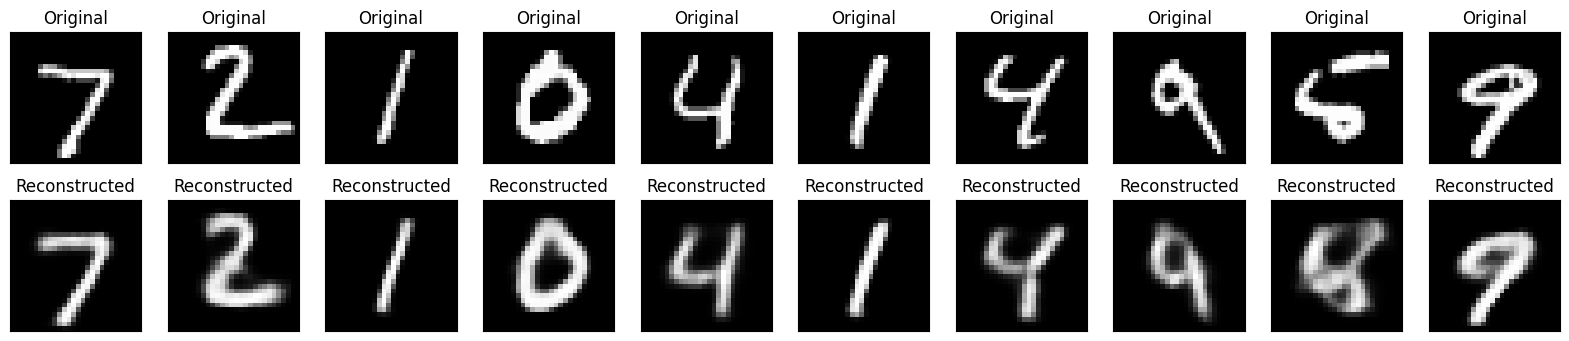

In [2]:
import matplotlib.pyplot as plt

# Generate reconstructed images
reconstructed_images = autoencoder.predict(x_test)

# Plot some of the original and reconstructed images
n = 10  # Number of images to plot
plt.figure(figsize=(20, 4))
for i in range(n):
    # Plot original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze())
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Plot reconstructed image
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(reconstructed_images[i].squeeze())
    plt.title("Reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [3]:
test_loss = autoencoder.evaluate(x_test, x_test)
print(f'Test loss: {test_loss:.4f}')

313/313 [==============================] - 1s 4ms/step - loss: 0.1258
Test loss: 0.1258


313/313 [==============================] - 0s 969us/step


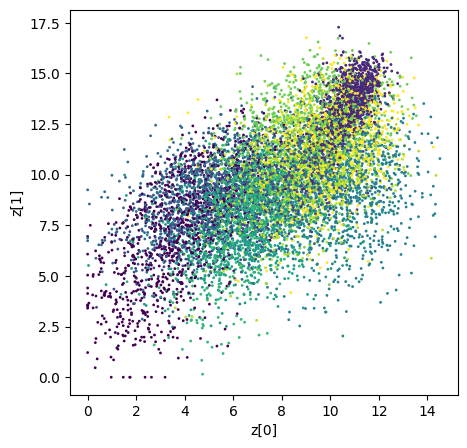

In [4]:
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib
#matplotlib.use('TkAgg')

# Encode the test dataset to get the latent vectors
encoded_imgs = encoder.predict(x_test)

# Get the labels for each image
labels = y_test

# Plot the latent vectors in 2D or 3D space using a scatter plot
fig = plt.figure(figsize=(5, 5))
#if latent_dim == 2:
plt.scatter(encoded_imgs[:, 1], encoded_imgs[:, 2], c=labels, cmap='viridis', s=1)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
#elif latent_dim == 3:
#    ax = fig.add_subplot(111, projection='3d')
#    ax.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], encoded_imgs[:, 2], c=labels, cmap='viridis')
#    ax.set_xlabel("z[0]")
#    ax.set_ylabel("z[1]")
#    ax.set_zlabel("z[2]")
#    plt.colorbar()
plt.show()


/Users/safaai/anaconda3/envs/Houman_Py/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


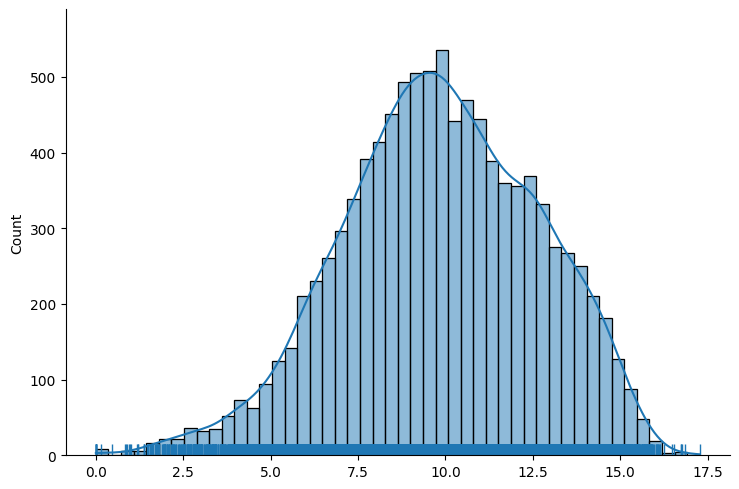

In [5]:
import seaborn as sns
import numpy as np

# Generate some random data
data = encoded_imgs[:, 2]
#np.random.normal(size=1000)

# Plot the kernel density estimate and the histogram
sns.displot(data, kde=True, rug=True, height=5, aspect=1.5)

313/313 [==============================] - 0s 1ms/step


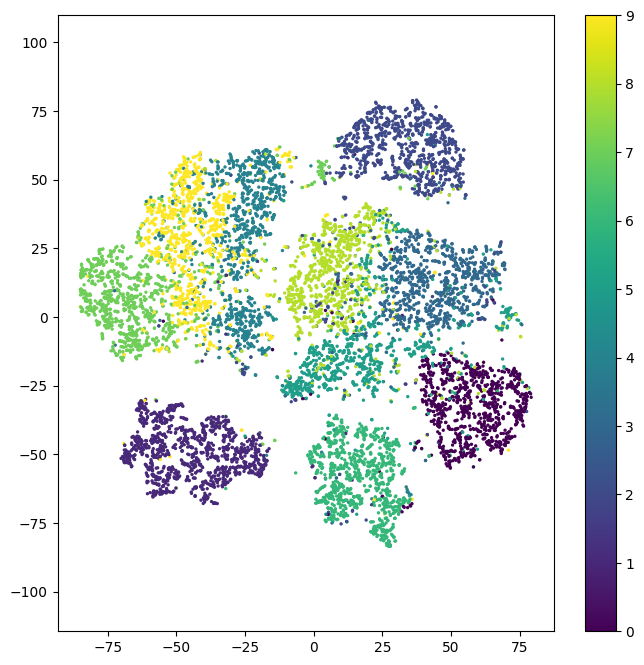

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Encode the test dataset to get the latent vectors
encoded_imgs = encoder.predict(x_test)

# Get the labels for each image
labels = y_test

# Use t-SNE to project the latent vectors to 2D space
tsne = TSNE(n_components=2, random_state=42)
encoded_imgs_tsne = tsne.fit_transform(encoded_imgs)

# Plot the t-SNE projection
fig = plt.figure(figsize=(8, 8))
plt.scatter(encoded_imgs_tsne[:, 0], encoded_imgs_tsne[:, 1], c=labels, cmap='viridis', s=2)
plt.colorbar()
plt.axis('equal')
plt.show()
